In [1]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import random

In [2]:
!pip install wandb
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: saniav2711 (ishaya-2716) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
class MOT17Dataset(Dataset):
    def __init__(self, mot_root, img_size=640, detector="DPM"):
        self.img_size = img_size
        self.samples = []
        mot_root = Path(mot_root)
        sequences = sorted([
            d for d in mot_root.iterdir()
            if d.is_dir() and d.name.endswith(f"-{detector}")
        ])
        print(f"Found {len(sequences)} sequences")
        for seq_dir in sequences:
            gt_path = seq_dir / "gt" / "gt.txt"
            img_dir = seq_dir / "img1"
            if not gt_path.exists():
                continue
            frame_boxes = {}
            with open(gt_path) as f:
                for line in f:
                    parts = line.strip().split(",")
                    if len(parts) < 8:
                        continue
                    frame_id = int(parts[0])
                    conf     = int(parts[6])
                    cls      = int(parts[7])
                    if conf != 1 or cls != 1:
                        continue
                    x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
                    x1, y1 = max(0, x), max(0, y)
                    x2, y2 = x1 + w, y1 + h
                    if w <= 0 or h <= 0:
                        continue
                    frame_boxes.setdefault(frame_id, []).append([x1, y1, x2, y2])
            for frame_id, boxes in frame_boxes.items():
                img_path = img_dir / f"{frame_id:06d}.jpg"
                if img_path.exists():
                    self.samples.append((str(img_path), boxes))
        print(f"Total samples: {len(self.samples)}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size))
        scale_x = self.img_size / w
        scale_y = self.img_size / h
        scaled_boxes = []
        for (x1, y1, x2, y2) in boxes:
            x1 = min(x1 * scale_x, self.img_size - 1)
            y1 = min(y1 * scale_y, self.img_size - 1)
            x2 = min(x2 * scale_x, self.img_size - 1)
            y2 = min(y2 * scale_y, self.img_size - 1)
            if x2 > x1 and y2 > y1:
                scaled_boxes.append([x1, y1, x2, y2])
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        if len(scaled_boxes) == 0:
            boxes_tensor  = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_tensor  = torch.tensor(scaled_boxes, dtype=torch.float32)
            labels_tensor = torch.ones(len(scaled_boxes), dtype=torch.int64)  # 1 = person
        target = {
            "boxes":  boxes_tensor,
            "labels": labels_tensor,
        }
        return img, target

Found 7 sequences
Total samples: 5316
Image shape: torch.Size([3, 640, 640])
Boxes: tensor([[446.0000, 247.7037, 501.6667, 472.2963],
        [195.3333, 264.8889, 223.6667, 420.7408],
        [472.0000, 255.4074, 533.3333, 454.5185]])
Labels: tensor([1, 1, 1])
x2>x1: tensor(True)
y2>y1: tensor(True)


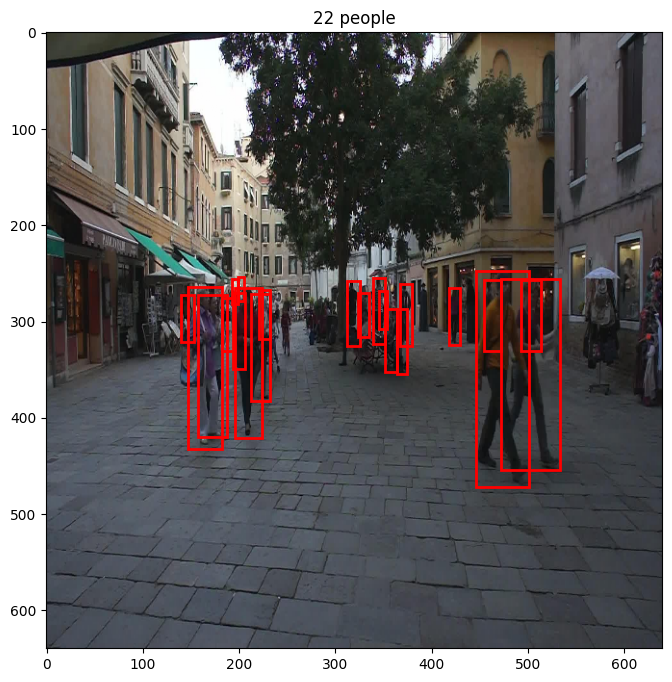

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MOT_ROOT = "/kaggle/input/datasets/saniaverma/newaefae"

dataset = MOT17Dataset(MOT_ROOT, img_size=640)
img, target = dataset[0]
print("Image shape:", img.shape)
print("Boxes:", target['boxes'][:3])
print("Labels:", target['labels'][:3])
print("x2>x1:", (target['boxes'][:,2] > target['boxes'][:,0]).all())
print("y2>y1:", (target['boxes'][:,3] > target['boxes'][:,1]).all())

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(img.permute(1,2,0))
for box in target['boxes']:
    x1,y1,x2,y2 = box
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
plt.title(f"{len(target['boxes'])} people")
plt.show()

In [6]:
from torch.utils.data import random_split, DataLoader
# Collate function
def collate_fn(batch):
    return tuple(zip(*batch))
dataset = MOT17Dataset("/kaggle/input/datasets/saniaverma/newaefae", img_size=640)

# 80/20 split with fixed generator
total      = len(dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                           generator=generator)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Found 7 sequences
Total samples: 5316
Train: 4252 | Val: 1064


In [7]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import resnet50
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

backbone = resnet50(weights="IMAGENET1K_V1")
backbone = torch.nn.Sequential(*list(backbone.children())[:-2])
backbone.out_channels = 2048


for name, param in backbone.named_parameters():
    param.requires_grad = False

anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)


roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=7,
    sampling_ratio=2
)

model = FasterRCNN(
    backbone=backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

model.to(device)

print("Model ready")

total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Using: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s] 


Model ready
Total params:     165,233,813
Trainable params: 141,725,781


In [8]:
from torch.optim.lr_scheduler import OneCycleLR
num_epochs = 30
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4,
)

scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader), 
    epochs=num_epochs,                  
    pct_start=0.1,                      
    anneal_strategy="cos",
)

In [9]:
import wandb
import gc
from tqdm import tqdm
import os
from IPython.display import FileLink, display
from IPython import get_ipython

num_epochs    = 30
best_val_loss = float('inf')

wandb.init(project="mot17-detection", name="baseline_without_fpn_again")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")
    model.train()
    train_loss = 0

    for imgs, targets in tqdm(train_loader, desc="Train"):
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  
        optimizer.step()
        scheduler.step()        

        train_loss += loss.item()
        del loss, loss_dict 

    avg_train_loss = train_loss / len(train_loader)
    print(f"Train Loss: {avg_train_loss:.4f}")

    model.train()              
    val_loss = 0

    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc="Val"):
            imgs    = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())
            val_loss += loss.item()
            del loss, loss_dict 

    model.eval()                

    avg_val_loss = val_loss / len(val_loader)
    print(f"Val Loss: {avg_val_loss:.4f}")

    wandb.log({
        "epoch":      epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss":   avg_val_loss,
        "lr":         optimizer.param_groups[0]['lr'],
    })

    # Save latest checkpoint
    checkpoint_path = "/kaggle/working/latest_checkpoint.pth"
    best_model_path = "/kaggle/working/baseline_withoutfpn.pth"

    torch.save({
        "epoch":           epoch + 1,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss":   best_val_loss,
    }, checkpoint_path)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model (val_loss: {avg_val_loss:.4f})")

    torch.cuda.empty_cache()
    gc.collect()

wandb.finish()

# =========================
# 📥 AUTO DOWNLOAD SECTION
# =========================

print("\nTraining complete. Preparing downloads...")

if os.path.exists(checkpoint_path):
    print("Checkpoint ready:")
    display(FileLink(checkpoint_path))
    
    # Force download
    get_ipython().system(f'cp {checkpoint_path} ./latest_checkpoint.pth')

if os.path.exists(best_model_path):
    print("Best model ready:")
    display(FileLink(best_model_path))
    
    # Force download
    get_ipython().system(f'cp {best_model_path} ./baseline_withoutfpn.pth')


===== Epoch 1/30 =====


Train: 100%|██████████| 1063/1063 [11:32<00:00,  1.54it/s]


Train Loss: 0.8636


Val: 100%|██████████| 266/266 [02:10<00:00,  2.05it/s]


Val Loss: 0.7031
Saved best model (val_loss: 0.7031)

===== Epoch 2/30 =====


...


Training complete. Preparing downloads...
Checkpoint ready:


/kaggle/working/latest_checkpoint.pth

cp: '/kaggle/working/latest_checkpoint.pth' and './latest_checkpoint.pth' are the same file
Best model ready:


/kaggle/working/baseline_withoutfpn.pth

cp: '/kaggle/working/baseline_withoutfpn.pth' and './baseline_withoutfpn.pth' are the same file


In [13]:
import shutil

shutil.make_archive("/kaggle/working/results", "zip", "/kaggle/working")

OSError: [Errno 28] No space left on device

In [15]:
import os

path = "/kaggle/working/baseline_withoutfpn.pth"
print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path) if os.path.exists(path) else "NO FILE")

Exists: True
Size: 661263743


In [21]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ── Backbone (same as training) ───────────────────────
backbone = resnet50(weights="IMAGENET1K_V1")
backbone = torch.nn.Sequential(*list(backbone.children())[:-2])
backbone.out_channels = 2048

# ── Anchor generator (MUST match training) ────────────
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# ── ROI pooler (MUST match training) ──────────────────
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=7,
    sampling_ratio=2
)

# ── Build model exactly like training ─────────────────
model = FasterRCNN(
    backbone=backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

# ── Load checkpoint ───────────────────────────────────
checkpoint_path = "/kaggle/working/baseline_withoutfpn.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# handle different saving formats
if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

model.load_state_dict(state_dict, strict=True)

# ── Move to device ────────────────────────────────────
model.to(device)
model.eval()

print("Model loaded successfully")

Using: cuda
Model loaded successfully


In [22]:
import torch

def box_iou(box1, box2):
    # box: [x1, y1, x2, y2]
    x1 = torch.max(box1[0], box2[0])
    y1 = torch.max(box1[1], box2[1])
    x2 = torch.min(box1[2], box2[2])
    y2 = torch.min(box1[3], box2[3])

    inter_w = (x2 - x1).clamp(min=0)
    inter_h = (y2 - y1).clamp(min=0)
    inter = inter_w * inter_h

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter + 1e-6

    return inter / union

In [23]:
import numpy as np
from tqdm import tqdm

model.eval()

all_ious = []
tp = 0
fp = 0
fn = 0
iou_threshold = 0.5

with torch.no_grad():
    for imgs, targets in tqdm(val_loader, desc="Evaluating"):

        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)

        for i in range(len(imgs)):

            pred_boxes = outputs[i]["boxes"].cpu()
            gt_boxes = targets[i]["boxes"]

            matched_gt = set()

            for pbox in pred_boxes:

                best_iou = 0
                best_gt_idx = -1

                for j, gtbox in enumerate(gt_boxes):

                    if j in matched_gt:
                        continue

                    iou = box_iou(pbox, gtbox)

                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j

                if best_iou >= iou_threshold:
                    tp += 1
                    matched_gt.add(best_gt_idx)
                    all_ious.append(best_iou)
                else:
                    fp += 1

            fn += (len(gt_boxes) - len(matched_gt))

Evaluating: 100%|██████████| 266/266 [03:38<00:00,  1.22it/s]


In [24]:
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)
mean_iou = np.mean(all_ious) if len(all_ious) > 0 else 0

print("\n===== FINAL METRICS =====")
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Mean IoU:  {mean_iou:.4f}")


===== FINAL METRICS =====
True Positives: 16378
False Positives: 44071
False Negatives: 5502
Precision: 0.2709
Recall:    0.7485
F1 Score:  0.3979
Mean IoU:  0.7321


In [25]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision(iou_type="bbox")  # gives mAP@0.5:0.95

In [26]:
model.eval()

metric.reset()

with torch.no_grad():
    for imgs, targets in val_loader:

        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)

        # move to CPU (torchmetrics requirement)
        preds = []
        gts = []

        for i in range(len(imgs)):

            preds.append({
                "boxes": outputs[i]["boxes"].cpu(),
                "scores": outputs[i]["scores"].cpu(),
                "labels": outputs[i]["labels"].cpu(),
            })

            gts.append({
                "boxes": targets[i]["boxes"].cpu(),
                "labels": targets[i]["labels"].cpu(),
            })

        metric.update(preds, gts)

In [27]:
results = metric.compute()

print("\n===== DETECTION METRICS =====")
print(f"mAP @ 0.50:        {results['map_50']:.4f}")
print(f"mAP @ 0.50:0.95:   {results['map']:.4f}")
print(f"mAR @ 100:         {results['mar_100']:.4f}")


===== DETECTION METRICS =====
mAP @ 0.50:        0.6110
mAP @ 0.50:0.95:   0.2978
mAR @ 100:         0.3963
